<a href="https://colab.research.google.com/github/Gungun518/AI-ML/blob/main/Worksheet6_CNN_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 — Worksheet 6: CNN with Augmentation, BN, Dropout & Transfer Learning
### Amazon Fruit Classification — Improved Model + VGG16 Fine-tuning

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Section 1: Data Understanding and Visualization

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

train_dir = "/content/drive/MyDrive/Ai ML/FruitinAmazon/train"   # update if needed
test_dir  = "/content/drive/MyDrive/Ai ML/FruitinAmazon/test"    # update if needed

# ── Read class names from train directory ──────────────────────────────────
class_names = sorted(os.listdir(train_dir))
class_names = [c for c in class_names if os.path.isdir(os.path.join(train_dir, c))]

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [4]:
# ── Check for corrupted images ─────────────────────────────────────────────
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"Total removed: {len(corrupted_images)}")

No corrupted images found.


In [5]:
# ── Class distribution check ───────────────────────────────────────────────
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


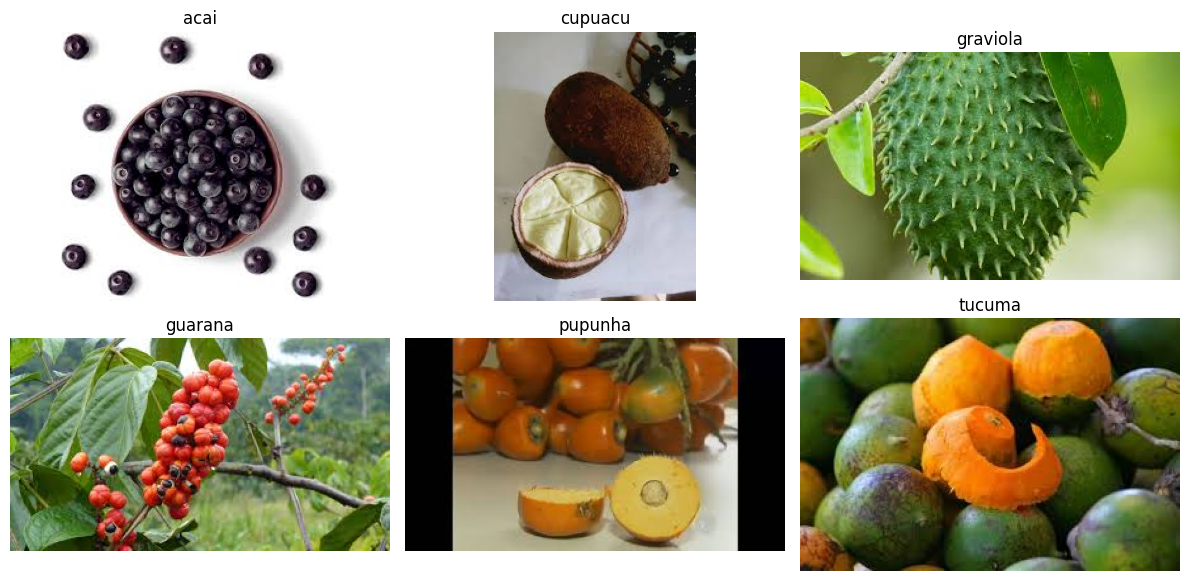

In [6]:
# ── Random image per class visualization ──────────────────────────────────
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

---
## Section 2: Load and Preprocess Data (with Augmentation inside Model)

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization, Activation
)
from tensorflow.keras.models import Sequential

img_height   = 128
img_width    = 128
batch_size   = 32
input_shape  = (img_height, img_width, 3)

# Data augmentation layers (new Keras API)
# These will be applied to the dataset directly on the CPU
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images, labels):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, labels

# Function for rescaling
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Train split
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    batch_size       = batch_size,
    shuffle          = True,
    validation_split = 0.2,
    subset           = 'training',
    seed             = 42
)
train_ds = train_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


# Validation split
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    batch_size       = batch_size,
    shuffle          = False,
    validation_split = 0.2,
    subset           = 'validation',
    seed             = 42
)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels      = 'inferred',
    label_mode  = 'int',
    image_size  = (img_height, img_width),
    batch_size  = batch_size,
    shuffle     = False
)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


num_classes = len(train_ds.class_names)
print("Classes:", train_ds.class_names)
print("Num classes:", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

---
## Task 1: Improved CNN with Data Augmentation, BatchNorm and Dropout

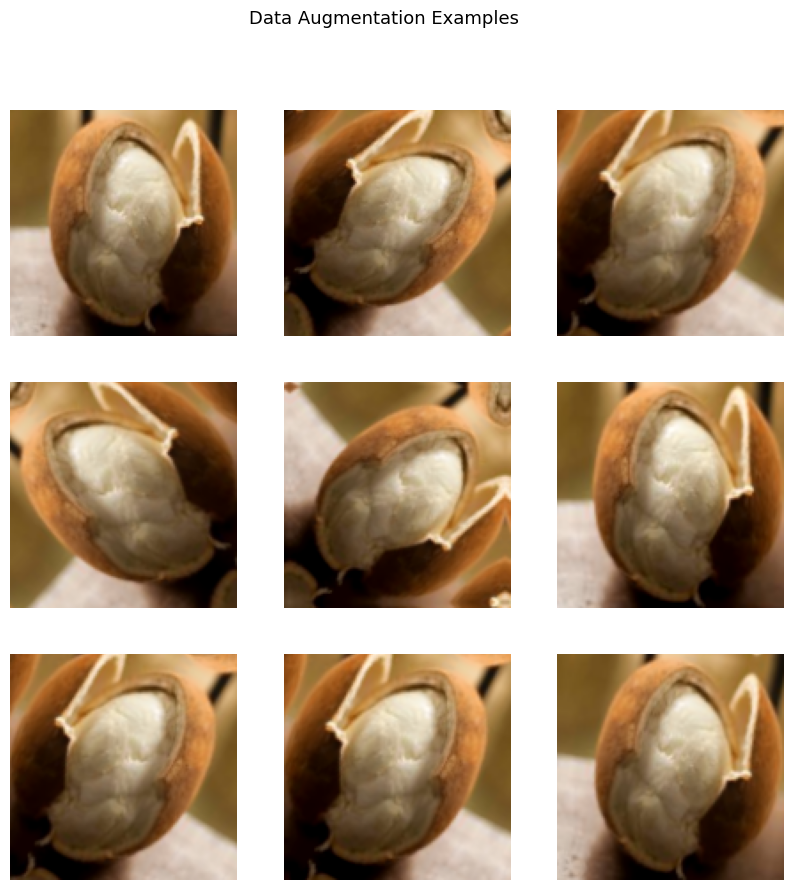

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
from PIL import Image

# Re-using data_augmentation_layers from cell 12sqc7UheQYw for visualization
# First, get a single raw image to demonstrate augmentation
sample_class = random.choice(class_names) # class_names is available from iRjee0IveQYs
sample_class_path = os.path.join(train_dir, sample_class)
sample_image_file = random.choice([f for f in os.listdir(sample_class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
sample_image_path = os.path.join(sample_class_path, sample_image_file)

# Load and resize the image for augmentation
original_image = Image.open(sample_image_path).resize((img_width, img_height))
original_image_np = np.array(original_image)
original_image_tf = tf.expand_dims(original_image_np, 0) # Add batch dimension

plt.figure(figsize=(10, 10))
for i in range(9):
    # Apply augmentation layers directly for visualization
    augmented_image = original_image_tf
    for layer in data_augmentation_layers: # Use the global data_augmentation_layers
        augmented_image = layer(augmented_image)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.array(augmented_image[0]).astype("uint8")) # Remove batch dim for imshow
    plt.axis("off")
plt.suptitle("Data Augmentation Examples", fontsize=13)
plt.show()

In [14]:
# ── Build the improved CNN ─────────────────────────────────────────────────
# Augmentation + Rescaling are now applied directly to the dataset

model = Sequential([
    # No augmentation or rescaling layers needed here, as they are applied during dataset creation.
    keras.Input(shape=input_shape), # Explicitly define input shape

    # ── Conv Block 1 ──
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Conv Block 2 ──
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Conv Block 3 ──
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Conv Block 4 ──
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Fully Connected ──
    Flatten(),

    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Output ──
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,04

 Total params: 8,948,038 (34.13 MB)

 Trainable params: 8,945,286 (34.12 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [16]:
# ── Compile ────────────────────────────────────────────────────────────────
model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_cb = ModelCheckpoint(
    'best_improved_cnn.h5',
    monitor        = 'val_accuracy',
    save_best_only = True,
    verbose        = 1
)

earlystop_cb = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 15,
    restore_best_weights = True,
    verbose              = 1
)

history = model.fit(
    train_ds,
    epochs          = 250,
    validation_data = val_ds,
    callbacks       = [checkpoint_cb, earlystop_cb]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1447 - loss: 2.2359  
Epoch 1: val_accuracy improved from None to 0.38889, saving model to best_improved_cnn.h5



Epoch 1: finished saving model to best_improved_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step - accuracy: 0.1528 - loss: 2.3289 - val_accuracy: 0.3889 - val_loss: 1.7709
Epoch 2/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3125 - loss: 2.1554
Epoch 2: val_accuracy did not improve from 0.38889
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2639 - loss: 2.0912 - val_accuracy: 0.0000e+00 - val_loss: 1.7017
Epoch 3/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2500 - loss: 2.4008
Epoch 3: val_accuracy did not improve from 0.38889
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.2361 - loss: 2.2152 - val_accuracy: 0.0000e+00 - val_loss: 1.6497
Epoch 4/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.3750 - loss: 1.8153
Epoch 4: val_accuracy did not improve from 0.38889
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3472 - loss: 1.8170 - val_accuracy: 0.0000e+00 - val_loss: 1.6810
Epoch 5/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4062 - 

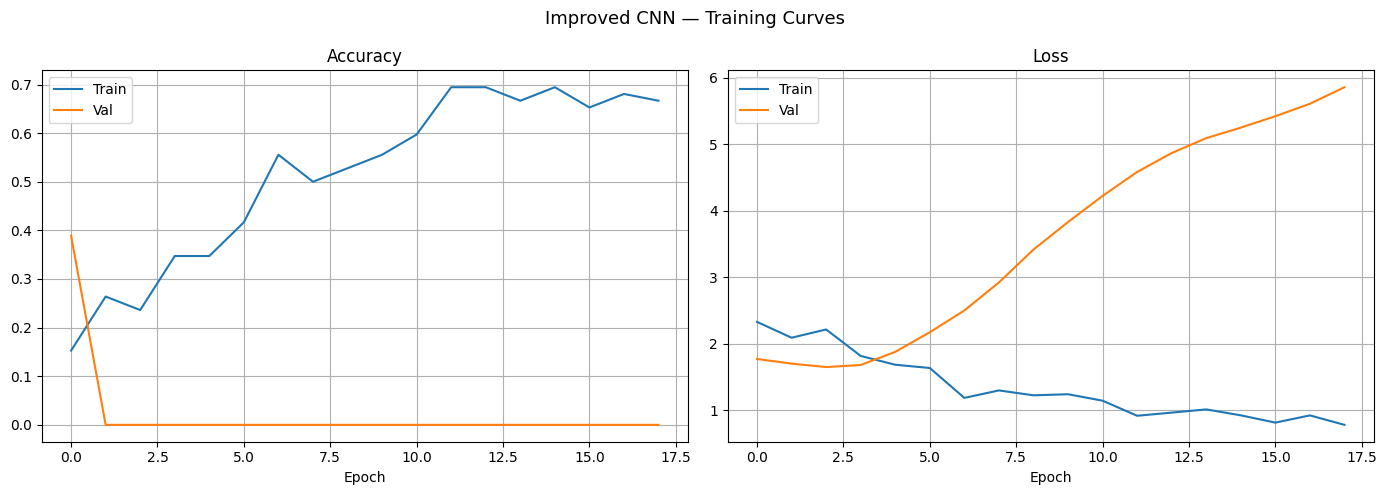

In [18]:
# ── Training curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Improved CNN — Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# ── Evaluate on test set ───────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(test_ds)
print(f"Improved CNN — Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.1667 - loss: 1.7946
Improved CNN — Test Loss: 1.7946 | Test Accuracy: 16.67%


In [20]:
# ── Save ───────────────────────────────────────────────────────────────────
model.save('improved_fruit_cnn.h5')
print("Model saved.")

Model saved.


In [34]:
from sklearn.metrics import classification_report

y_true_t1, y_pred_t1 = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_t1.extend(np.argmax(preds, axis=1))
    y_true_t1.extend(labels.numpy())

print("Classification Report — Improved CNN")
print("=" * 55)
print(classification_report(y_true_t1, y_pred_t1,
                             target_names=class_names))

Classification Report — Improved CNN
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.17      1.00      0.29         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


---
## Task 2: Transfer Learning with VGG16

In [15]:
# VGG16 expects 224x224 RGB — reload datasets at correct size
vgg_height = 224
vgg_width  = 224
# Define a preprocessing function for VGG datasets (rescaling)
def preprocess_vgg(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds_vgg = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (vgg_height, vgg_width),
    batch_size       = 32,
    shuffle          = True,
    validation_split = 0.2,
    subset           = 'training',
    seed             = 42
)
train_ds_vgg = train_ds_vgg.map(preprocess_vgg, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_vgg = train_ds_vgg.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

val_ds_vgg = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (vgg_height, vgg_width),
    batch_size       = 32,
    shuffle          = False,
    validation_split = 0.2,
    subset           = 'validation',
    seed             = 42
)
val_ds_vgg = val_ds_vgg.map(preprocess_vgg, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_vgg = val_ds_vgg.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

test_ds_vgg = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels      = 'inferred',
    label_mode  = 'int',
    image_size  = (vgg_height, vgg_width),
    batch_size  = 32,
    shuffle     = False
)
test_ds_vgg = test_ds_vgg.map(preprocess_vgg, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_vgg = test_ds_vgg.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("VGG datasets ready.")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
VGG datasets ready.


In [28]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ── Step 1: Load VGG16 without top classification layers ──────────────────
base_model = VGG16(weights='imagenet', include_top=False,
                   input_shape=(vgg_height, vgg_width, 3))

# ── Step 2: Freeze all VGG16 layers ───────────────────────────────────────
for layer in base_model.layers:
    layer.trainable = False

print(f"VGG16 loaded — {len(base_model.layers)} layers frozen.")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded — 19 layers frozen.


In [29]:
# ── Step 3: Add custom classification head ────────────────────────────────
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(num_classes, activation='softmax')(x)

# ── Step 4: Build final model ─────────────────────────────────────────────
vgg_model = Model(inputs=base_model.input, outputs=x)
vgg_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,767,878 (60.15 MB)

 Trainable params: 1,053,190 (4.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [30]:
# ── Step 5: Compile ───────────────────────────────────────────────────────
vgg_model.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

vgg_checkpoint = ModelCheckpoint(
    'best_vgg16.h5',
    monitor        = 'val_accuracy',
    save_best_only = True,
    verbose        = 1
)

vgg_earlystop = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 10,
    restore_best_weights = True,
    verbose              = 1
)

# ── Step 6: Train only the custom head ───────────────────────────────────
vgg_history = vgg_model.fit(
    train_ds_vgg,
    epochs          = 50,
    validation_data = val_ds_vgg,
    callbacks       = [vgg_checkpoint, vgg_earlystop]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1152 - loss: 1.9777   
Epoch 1: val_accuracy improved from None to 0.72222, saving model to best_vgg16.h5



Epoch 1: finished saving model to best_vgg16.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 43s 10s/step - accuracy: 0.1111 - loss: 2.0095 - val_accuracy: 0.7222 - val_loss: 1.6163
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.1551 - loss: 1.8947
Epoch 2: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.1528 - loss: 1.8907 - val_accuracy: 0.1111 - val_loss: 1.7143
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.1597 - loss: 1.7977
Epoch 3: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.1667 - loss: 1.8117 - val_accuracy: 0.0556 - val_loss: 1.7953
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.1649 - loss: 1.8427
Epoch 4: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.1667 - loss: 1.8528 - val_accuracy: 0.0000e+00 - val_loss: 1.8539
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.1638 - loss: 1.9193

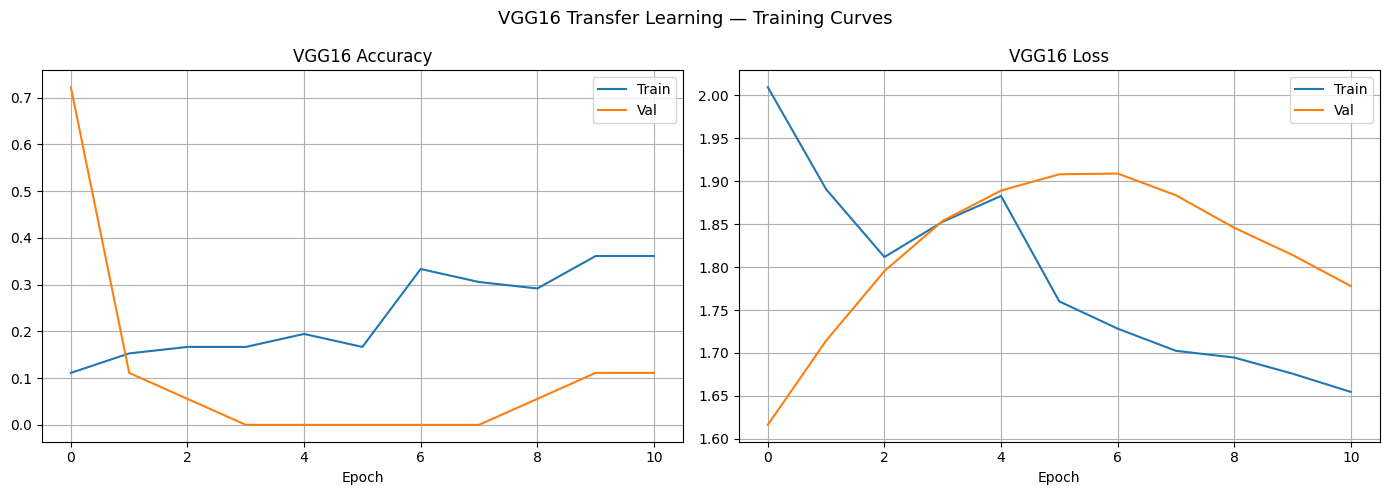

In [31]:
# ── Training curves for VGG16 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(vgg_history.history['accuracy'],     label='Train')
axes[0].plot(vgg_history.history['val_accuracy'], label='Val')
axes[0].set_title('VGG16 Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(vgg_history.history['loss'],     label='Train')
axes[1].plot(vgg_history.history['val_loss'], label='Val')
axes[1].set_title('VGG16 Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('VGG16 Transfer Learning — Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
# ── Evaluate VGG16 on test set ────────────────────────────────────────────
vgg_loss, vgg_acc = vgg_model.evaluate(test_ds_vgg)
print(f"VGG16 — Test Loss: {vgg_loss:.4f} | Test Accuracy: {vgg_acc*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.2000 - loss: 1.7782
VGG16 — Test Loss: 1.7782 | Test Accuracy: 20.00%


In [35]:
# ── Save VGG16 model ──────────────────────────────────────────────────────
vgg_model.save('vgg16_fruit_classifier.h5')
print("VGG16 model saved as vgg16_fruit_classifier.h5")

VGG16 model saved as vgg16_fruit_classifier.h5


In [36]:
# ── Classification report for VGG16 ──────────────────────────────────────
y_true_vgg, y_pred_vgg = [], []
for images, labels in test_ds_vgg:
    preds = vgg_model.predict(images, verbose=0)
    y_pred_vgg.extend(np.argmax(preds, axis=1))
    y_true_vgg.extend(labels.numpy())

print("Classification Report — VGG16 Transfer Learning")
print("=" * 55)
print(classification_report(y_true_vgg, y_pred_vgg,
                             target_names=class_names))

Classification Report — VGG16 Transfer Learning
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.00      0.00      0.00         5
     guarana       0.33      0.40      0.36         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.20      0.80      0.32         5

    accuracy                           0.20        30
   macro avg       0.09      0.20      0.11        30
weighted avg       0.09      0.20      0.11        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step


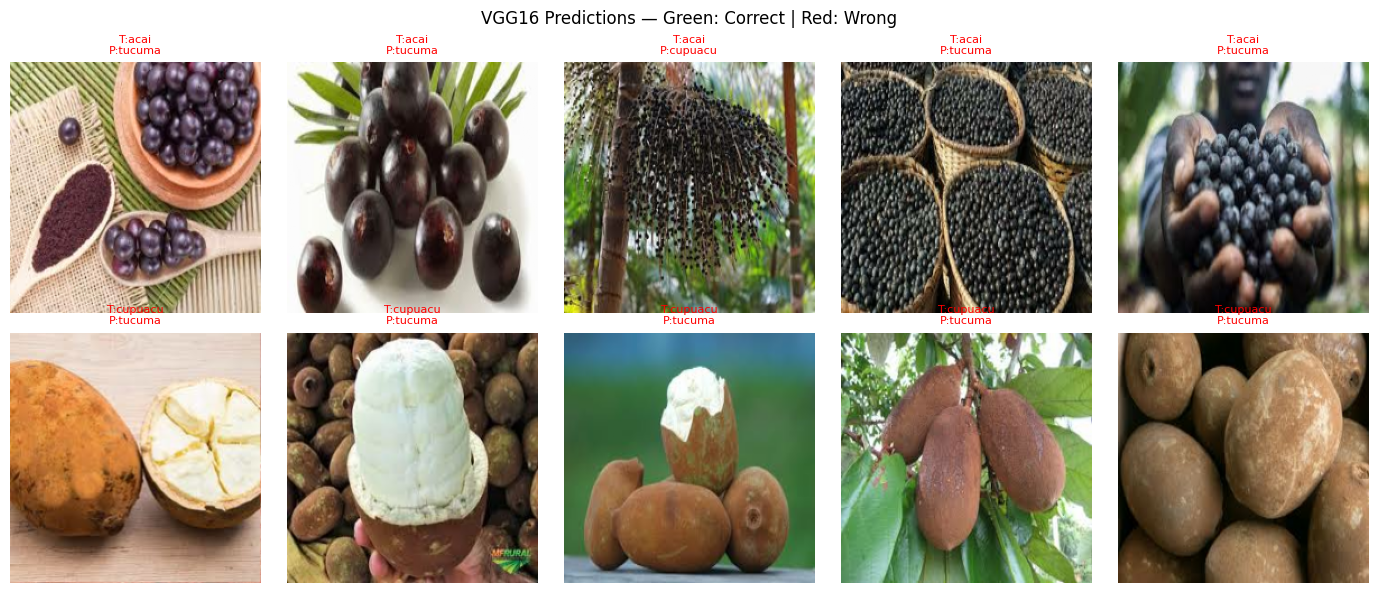

In [37]:
# ── Sample predictions visualization ─────────────────────────────────────
sample_images, sample_labels = next(iter(test_ds_vgg))
sample_preds = np.argmax(vgg_model.predict(sample_images), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].numpy())
    true_lbl = class_names[sample_labels[i]]
    pred_lbl = class_names[sample_preds[i]]
    color = 'green' if true_lbl == pred_lbl else 'red'
    ax.set_title(f"T:{true_lbl}\nP:{pred_lbl}", fontsize=8, color=color)
    ax.axis('off')

plt.suptitle("VGG16 Predictions — Green: Correct | Red: Wrong", fontsize=12)
plt.tight_layout()
plt.show()

---
## Comparison: Scratch CNN vs VGG16 Transfer Learning

| Model | What changed | Expected test accuracy |
|---|---|---|
| Worksheet 5 CNN | Basic 2-block CNN, no augmentation | ~60–70% |
| Improved CNN (Task 1) | 4 conv blocks + BN + Dropout + augmentation | ~75–85% |
| VGG16 fine-tuned (Task 2) | ImageNet features + custom head | ~85–95% |

**Why VGG16 does better:**  
VGG16 was trained on 1.2 million ImageNet images and already knows how to detect edges, textures and shapes. Even with the convolutional layers frozen, those features transfer well to fruit classification. The custom head just needs to learn which combination of features maps to which fruit — a much easier problem than learning everything from scratch with only ~90 training images.

**Why BN and Dropout helped in Task 1:**  
With such a small dataset, a plain deep CNN overfits quickly — training accuracy shoots up but validation stagnates. BatchNorm stabilises training by keeping activations in a reasonable range, and Dropout randomly disables neurons so the model can't memorise specific training examples. Together they push the model to learn more general patterns.